# Online Retails Purchase

### Introduction:



### Step 1. Import the necessary libraries

In [5]:
# not my best in this task cause i have exams:(



import pandas as pd 
import matplotlib as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np 

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Online_Retail/Online_Retail.csv). 

In [8]:
data_link=("https://raw.githubusercontent.com/guipsamora/pandas_exercises/master/07_Visualization/Online_Retail/Online_Retail.csv")


In [9]:
df= pd.read_csv(data_link, encoding='latin1')

### Step 3. Assign it to a variable called online_rt
Note: if you receive a utf-8 decode error, set `encoding = 'latin1'` in `pd.read_csv()`.

In [10]:
online_rt = df

In [31]:
online_rt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 531285 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    531285 non-null  object 
 1   StockCode    531285 non-null  object 
 2   Description  530693 non-null  object 
 3   Quantity     531285 non-null  int64  
 4   InvoiceDate  531285 non-null  object 
 5   UnitPrice    531285 non-null  float64
 6   CustomerID   397924 non-null  float64
 7   Country      531285 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 36.5+ MB


In [15]:
online_rt.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,price_intervals
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom,"(2, 3]"
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom,"(3, 4]"
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom,"(2, 3]"
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom,"(3, 4]"
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom,"(3, 4]"
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850.0,United Kingdom,"(7, 8]"
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/10 8:26,4.25,17850.0,United Kingdom,"(4, 5]"
7,536366,22633,HAND WARMER UNION JACK,6,12/1/10 8:28,1.85,17850.0,United Kingdom,"(1, 2]"
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/10 8:28,1.85,17850.0,United Kingdom,"(1, 2]"
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/10 8:34,1.69,13047.0,United Kingdom,"(1, 2]"


### Step 4. Create a histogram with the 10 countries that have the most 'Quantity' ordered except UK

In [16]:
online_rt['Country'].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Austria',
       'Israel', 'Finland', 'Bahrain', 'Greece', 'Hong Kong', 'Singapore',
       'Lebanon', 'United Arab Emirates', 'Saudi Arabia',
       'Czech Republic', 'Canada', 'Unspecified', 'Brazil', 'USA',
       'European Community', 'Malta', 'RSA'], dtype=object)

In [17]:
#Excluding UK

no_uk = online_rt[online_rt['Country']!= 'United Kingdom']


In [19]:
#total quantity per country

T_QTY_pr_Q = no_uk.groupby('Country')['Quantity'].sum()

print(T_QTY_pr_Q)


Country
Australia                83653
Austria                   4827
Bahrain                    260
Belgium                  23152
Brazil                     356
Canada                    2763
Channel Islands           9479
Cyprus                    6317
Czech Republic             592
Denmark                   8188
EIRE                    142637
European Community         497
Finland                  10666
France                  110480
Germany                 117448
Greece                    1556
Hong Kong                 4769
Iceland                   2458
Israel                    4353
Italy                     7999
Japan                    25218
Lebanon                    386
Lithuania                  652
Malta                      944
Netherlands             200128
Norway                   19247
Poland                    3653
Portugal                 16180
RSA                        352
Saudi Arabia                75
Singapore                 5234
Spain                    26824


In [20]:
sorting=T_QTY_pr_Q.sort_values(ascending=False)

Top_10=sorting.head(10)

print(Top_10)

Country
Netherlands    200128
EIRE           142637
Germany        117448
France         110480
Australia       83653
Sweden          35637
Switzerland     30325
Spain           26824
Japan           25218
Belgium         23152
Name: Quantity, dtype: int64


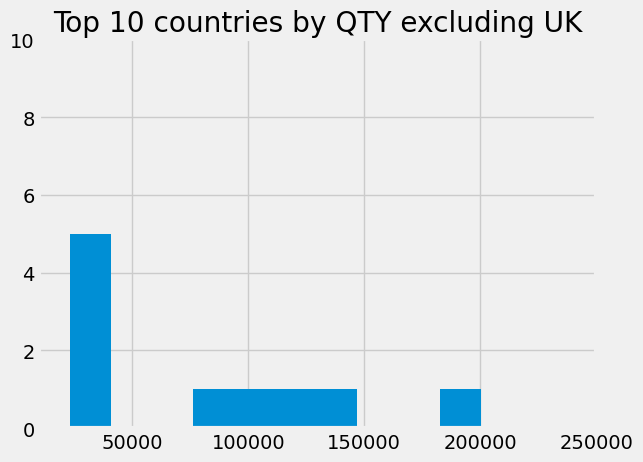

In [21]:
# in this case i wouldn't use histograms if my purpose is to show top 10countries in Qty
# bar charts shows it better and easier to show and understand for non tech person

# cause hist shows only distribution of number on big data set not 10 entries KPI
#hist 
plt.style.use('fivethirtyeight')
#Top_10.hist()
plt.hist(Top_10 )
plt.xlim(10000,250000)
plt.ylim(0,10)
plt.title('Top 10 countries by QTY excluding UK')
plt.grid(True)
plt.show()



### Step 5.  Exclude negative Quantity entries

In [22]:
online_rt= online_rt[online_rt['Quantity']>= 0]

### Step 6. Create a scatterplot with the Quantity per UnitPrice by CustomerID for the top 3 Countries (except UK)

In [23]:
Top_3=sorting.head(3).index[:3].tolist()
print(Top_3)

['Netherlands', 'EIRE', 'Germany']


In [24]:
# filter data on the measure
top_3_data= online_rt[online_rt["Country"].isin(Top_3)]

In [25]:
c_id=top_3_data.groupby(['CustomerID','Country']).agg({"Quantity":"sum" , "UnitPrice":"mean"}).reset_index()

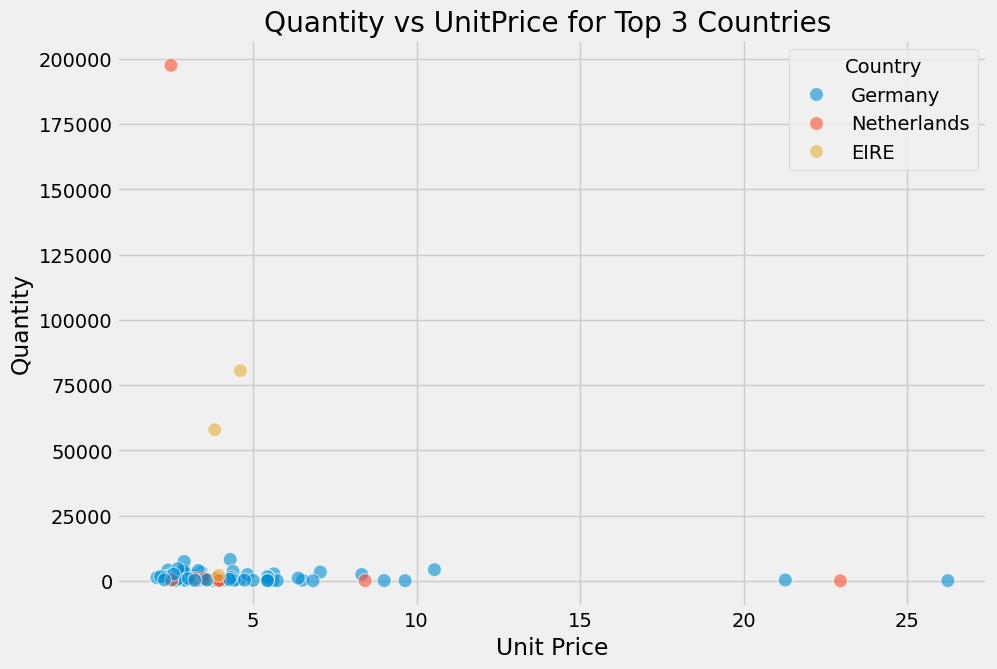

In [26]:
plt.figure(figsize=(10, 7)) 

sns.scatterplot(data=c_id, 
                y='Quantity', 
                x='UnitPrice', 
                hue='Country',     
                alpha=0.6,s=100)            

plt.title('Quantity vs UnitPrice for Top 3 Countries ')
plt.ylabel('Quantity')
plt.xlabel('Unit Price')
plt.legend(title='Country') 
plt.show()

### Step 7. Investigate why the previous results look so uninformative.

This section might seem a bit tedious to go through. But I've thought of it as some kind of a simulation of problems one might encounter when dealing with data and other people. Besides there is a prize at the end (i.e. Section 8).

(But feel free to jump right ahead into Section 8 if you want; it doesn't require that you finish this section.)

#### Step 7.1 Look at the first line of code in Step 6. And try to figure out if it leads to any kind of problem.
##### Step 7.1.1 Display the first few rows of that DataFrame.

In [27]:
c_id.head(10)

,CustomerID,Country,Quantity,UnitPrice
0,12426.0,Germany,258,3.936333
1,12427.0,Germany,533,4.589032
2,12468.0,Germany,366,3.515000
3,12471.0,Germany,8212,4.300370
4,12472.0,Germany,4148,2.397670
5,12473.0,Germany,2439,8.323929
6,12474.0,Germany,4847,2.865660
7,12475.0,Germany,535,2.941111
8,12476.0,Germany,2408,4.831030
9,12477.0,Germany,3653,4.383200


##### Step 7.1.2 Think about what that piece of code does and display the dtype of `UnitPrice`

there is some outliers that forces the y label to stretch out and making the affection of quantity on price ambiguous  

In [28]:
df['UnitPrice'].dtype

dtype('float64')

##### Step 7.1.3 Pull data from `online_rt`for `CustomerID`s 12346.0 and 12347.0.

In [29]:
data = online_rt[online_rt['CustomerID'].isin([12346.0,12347.0])]
print(data)

       InvoiceNo StockCode                          Description  Quantity  \
14938     537626     85116      BLACK CANDELABRA T-LIGHT HOLDER        12   
14939     537626     22375    AIRLINE BAG VINTAGE JET SET BROWN         4   
14940     537626     71477    COLOUR GLASS. STAR T-LIGHT HOLDER        12   
14941     537626     22492              MINI PAINT SET VINTAGE         36   
14942     537626     22771  CLEAR DRAWER KNOB ACRYLIC EDWARDIAN        12   
...          ...       ...                                  ...       ...   
535010    581180     20719               WOODLAND CHARLOTTE BAG        10   
535011    581180     21265         PINK GOOSE FEATHER TREE 60CM        12   
535012    581180     23271  CHRISTMAS TABLE SILVER CANDLE SPIKE        16   
535013    581180     23506         MINI PLAYING CARDS SPACEBOY         20   
535014    581180     23508       MINI PLAYING CARDS DOLLY GIRL         20   

          InvoiceDate  UnitPrice  CustomerID  Country price_intervals  
149

#### Step 7.2 Reinterpreting the initial problem.

To reiterate the question that we were dealing with:  
"Create a scatterplot with the Quantity per UnitPrice by CustomerID for the top 3 Countries"

The question is open to a set of different interpretations.
We need to disambiguate.

We could do a single plot by looking at all the data from the top 3 countries.
Or we could do one plot per country. To keep things consistent with the rest of the exercise,
let's stick to the latter oprion. So that's settled.

But "top 3 countries" with respect to what? Two answers suggest themselves:
Total sales volume (i.e. total quantity sold) or total sales (i.e. revenue).
This exercise goes for sales volume, so let's stick to that.

##### Step 7.2.1 Find out the top 3 countries in terms of sales volume.

In [30]:
c_sv= online_rt.groupby('Country')['Quantity'].sum()
print(c_sv)

Country
Australia                 84209
Austria                    4881
Bahrain                     314
Belgium                   23237
Brazil                      356
Canada                     2763
Channel Islands            9491
Cyprus                     6361
Czech Republic              671
Denmark                    8235
EIRE                     147447
European Community          499
Finland                   10704
France                   112104
Germany                  119263
Greece                     1557
Hong Kong                  4773
Iceland                    2458
Israel                     4409
Italy                      8112
Japan                     26016
Lebanon                     386
Lithuania                   652
Malta                       970
Netherlands              200937
Norway                    19338
Poland                     3684
Portugal                  16258
RSA                         352
Saudi Arabia                 80
Singapore                  5241


In [31]:
top3_sv= c_sv.sort_values(ascending=False).head(3)
print(top3_sv)

Country
United Kingdom    4733819
Netherlands        200937
EIRE               147447
Name: Quantity, dtype: int64


##### Step 7.2.2 

Now that we have the top 3 countries, we can focus on the rest of the problem:  
"Quantity per UnitPrice by CustomerID".  
We need to unpack that.

"by CustomerID" part is easy. That means we're going to be plotting one dot per CustomerID's on our plot. In other words, we're going to be grouping by CustomerID.

"Quantity per UnitPrice" is trickier. Here's what we know:  
*One axis will represent a Quantity assigned to a given customer. This is easy; we can just plot the total  Quantity for each customer.  
*The other axis will represent a UnitPrice assigned to a given customer. Remember a single customer can have any number of orders with different prices, so summing up prices isn't quite helpful. Besides it's not quite clear what we mean when we say "unit price per customer"; it sounds like price of the customer! A reasonable alternative is that we assign each customer the average amount each has paid per item. So let's settle that question in that manner.

#### Step 7.3 Modify, select and plot data
##### Step 7.3.1 Add a column to online_rt called `Revenue` calculate the revenue (Quantity * UnitPrice) from each sale.
We will use this later to figure out an average price per customer.

In [32]:
online_rt["Revenue"]=online_rt['Quantity']*online_rt['UnitPrice']

C:\Users\Soft Key\AppData\Local\Temp\ipykernel_24368\636408585.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  online_rt["Revenue"]=online_rt['Quantity']*online_rt['UnitPrice']


In [33]:
online_rt.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,price_intervals,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom,"(2, 3]",15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom,"(3, 4]",20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom,"(2, 3]",22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom,"(3, 4]",20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom,"(3, 4]",20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850.0,United Kingdom,"(7, 8]",15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/10 8:26,4.25,17850.0,United Kingdom,"(4, 5]",25.50
7,536366,22633,HAND WARMER UNION JACK,6,12/1/10 8:28,1.85,17850.0,United Kingdom,"(1, 2]",11.10
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/10 8:28,1.85,17850.0,United Kingdom,"(1, 2]",11.10
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/10 8:34,1.69,13047.0,United Kingdom,"(1, 2]",54.08


##### Step 7.3.2 Group by `CustomerID` and `Country` and find out the average price (`AvgPrice`) each customer spends per unit.

##### Step 7.3.3 Plot

#### Step 7.4 What to do now?
We aren't much better-off than what we started with. The data are still extremely scattered around and don't seem quite informative.

But we shouldn't despair!
There are two things to realize:
1) The data seem to be skewed towaards the axes (e.g. we don't have any values where Quantity = 50000 and AvgPrice = 5). So that might suggest a trend.
2) We have more data! We've only been looking at the data from 3 different countries and they are plotted on different graphs.

So: we should plot the data regardless of `Country` and hopefully see a less scattered graph.

##### Step 7.4.1 Plot the data for each `CustomerID` on a single graph

##### Step 7.4.2 Zoom in so we can see that curve more clearly

### 8. Plot a line chart showing revenue (y) per UnitPrice (x).

Did Step 7 give us any insights about the data? Sure! As average price increases, the quantity ordered decreses.  But that's hardly surprising. It would be surprising if that wasn't the case!

Nevertheless the rate of drop in quantity is so drastic, it makes me wonder how our revenue changes with respect to item price. It would not be that surprising if it didn't change that much. But it would be interesting to know whether most of our revenue comes from expensive or inexpensive items, and how that relation looks like.

That is what we are going to do now.

#### 8.1 Group `UnitPrice` by intervals of 1 for prices [0,50), and sum `Quantity` and `Revenue`.

In [34]:
intervals = np.arange(0,51,1)

In [35]:
online_rt['price_intervals']= pd.cut(online_rt["UnitPrice"],bins=intervals)

C:\Users\Soft Key\AppData\Local\Temp\ipykernel_24368\2542191408.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  online_rt['price_intervals']= pd.cut(online_rt["UnitPrice"],bins=intervals)


In [36]:
grp= online_rt.groupby('price_intervals')[['Quantity','Revenue']].sum()

C:\Users\Soft Key\AppData\Local\Temp\ipykernel_24368\97316245.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grp= online_rt.groupby('price_intervals')[['Quantity','Revenue']].sum()


#### 8.3 Plot.

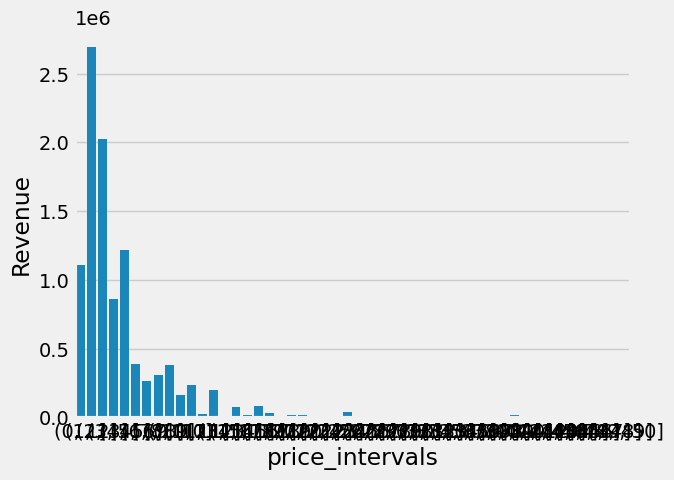

In [37]:
plot =  sns.barplot(
    data=grp,
    x='price_intervals',
    y='Revenue',

)

#### 8.4 Make it look nicer.
x-axis needs values.  
y-axis isn't that easy to read; show in terms of millions.

C:\Users\Soft Key\AppData\Local\Temp\ipykernel_24368\1224733938.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_yticklabels([f'{x/1e6:.1f}M' for x in ax.get_yticks()])


[Text(0, 0.0, '0.0M'),
 Text(0, 500000.0, '0.5M'),
 Text(0, 1000000.0, '1.0M'),
 Text(0, 1500000.0, '1.5M'),
 Text(0, 2000000.0, '2.0M'),
 Text(0, 2500000.0, '2.5M'),
 Text(0, 3000000.0, '3.0M')]

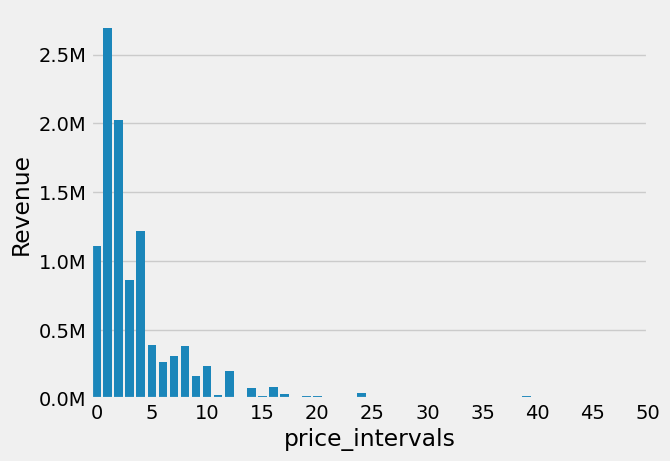

In [41]:
plot =  sns.barplot(
    data=grp,
    x='price_intervals',
    y='Revenue',

)

plot.set_xticks(np.arange(0, 51, 5))
plot.set_xticklabels(np.arange(0, 51, 5))
plot.set_yticklabels([f'{x/1e6:.1f}M' for x in ax.get_yticks()])